# Tune $D_{sei}$ to get SEI quality for different formation protocols

2025/04/16

The plan:
1. Define an objective function as some combination of expansion error and voltage error
1. Sweep through different values of D_sei for VC only (just start with VC for now)
1. Plot D_sei vs error function for the three different formation protocols

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from src import plotter as plotter

%load_ext autoreload

plotter.initialize(plt)

target_dir = os.getcwd()

# Load the Experimental Data

In [4]:
def fetch_file_list(cellid):

    target_dir_arbin = f'{target_dir}/data/raw/from-voltaiq'


    if cellid == 152064:
        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
                        ]

        daq_channel = 'Key_CH1'

        hr_max = 20*24

    elif cellid == 152074: # BASELINE FORMATION (repeat 2)

        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv'
                        ]

        daq_channel = 'Key_CH0'

        hr_max = 20*24

    elif cellid == 152071: # FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH3'

        hr_max = 20*24

    elif cellid == 152098: # SUPER FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMFAST_2_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH2'

        hr_max = 20*24


    return file_arbin_list, daq_channel, hr_max


In [2]:
def fetch_experimental_data(cellid, max_hours=1000000):

    # To make the dQ/dV plot work, be sure to only select the FORM protocol without
    # including the aging file. Otherwise the time vector will be confused.
    file_indices_to_include = np.array([1,2])

    file_arbin_list, daq_channel, hr_max = fetch_file_list(cellid)


    # Load the Arbin Data
    df_arbin_list = []

    for file in np.array(file_arbin_list)[file_indices_to_include]:

        df = pd.read_csv(file)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Timestamp']= df['Timestamp'].apply(lambda x : x.tz_localize(None))
        df_arbin_list.append(df)

    df_arbin = pd.concat(df_arbin_list, axis=0)

    # Filter the Arbin Data
    qq = df_arbin['Charge Capacity (Ah)']
    tv = df_arbin['Timestamp'].astype(int)
    tv = (tv - np.min(tv)) / 1e9
    y_voltage = df_arbin['Potential (V)']
    y_current = df_arbin['Current (A)']

    y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.NaN
    y_current.iloc[np.where(tv/3600 > hr_max)] = np.NaN

    # Load the Keyence data
    file_keyence = f'{target_dir}/data/raw/from-keyence/keyence_20220901_213928.csv'
    df_keyence = pd.read_csv(file_keyence)
    df_keyence['computer time'] = pd.to_datetime(df_keyence['computer time'], unit='s')
    df_keyence['computer time'] = df_keyence['computer time'].apply(lambda x : x.tz_localize(None))

    # Filter the Keyence data
    df_keyence = df_keyence.loc[(df_keyence['computer time'] > df_arbin['Timestamp'].iloc[0]) & \
                                (df_keyence['computer time'] < df_arbin['Timestamp'].iloc[-1])]
    y_strain = df_keyence[daq_channel] - df_keyence[daq_channel].iloc[0]
    y_strain[y_strain > 500] = np.NaN

    tt = df_keyence['computer time'].astype(int)
    tt = (tt - np.min(tt)) / 1e9

    y_strain.iloc[np.where(tt/3600 > hr_max)] = np.NaN

    out = dict()

    idx = np.where(tv < max_hours*3600)[0]
    out['arbin_time'] = tv.iloc[idx]
    out['arbin_voltage'] = y_voltage.iloc[idx]
    out['arbin_current'] = y_current.iloc[idx]

    idx = np.where(tt < max_hours * 3600)[0]
    out['daq_time'] = tt.iloc[idx]
    out['daq_strain'] = y_strain.iloc[idx]

    return out


# Load the experimental data

In [5]:
expt1 = fetch_experimental_data(152064)
expt2 = fetch_experimental_data(152074)
expt3 = fetch_experimental_data(152071, 16)
expt4 = fetch_experimental_data(152098, 7)

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_77185/704863275.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.NaN
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_77185/704863275.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_current.iloc[np.where(tv/3600 > hr_max)] = np.NaN
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_77185/704863275.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

# Run the simulation: baseline formation

In [ ]:
%autoreload
Ichg = 2.5/10  # A
Idch = -2.5/10 # A
Icv = 2.5/20   # A

vmax = 4.2
vmin = 3.0

cell = cellsim.Cell()
cell.load_config('params/default.yaml')

# sim = cellsim.Simulation(cell, 520*3600)
sim1 = cellsim.Simulation(cell, 80*3600)

# Formation
sim1.run_rest(1, rest_time_hrs=0.5)
sim1.run_chg_cccv(2, 2.5/10, Icv, vmax)
sim1.run_dch_cccv(2, Idch, Idch, vmin)
sim1.run_chg_cccv(3, 2.5/10, Icv, vmax)
sim1.run_dch_cccv(3, Idch, Idch, vmin)
sim1.run_chg_cccv(4, 2.5/10, Icv, vmax)
sim1.run_dch_cccv(4, Idch, 0.05, vmin)
sim1.run_rest(4, rest_time_hrs=6)

sim1_time1 = sim1.get_results()['t'].iloc[-1]/3600

df_sim1 = sim1.get_results()


Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...


In [9]:
# Get the results from sim1
results = sim1.get_results()

# Create a DataFrame with the resistance values
df_resistance = pd.DataFrame({
    'R_sei (total)': results['R_sei'],
    'R_sei1 (EC)': results['R_sei1'],
    'R_sei2 (VC)': results['R_sei2'],
    'Delta_sei1' : results['delta_sei1'],
    'Delta_sei2' : results['delta_sei2'],
    'kappa_sei1': results['kappa_sei1'],
    'kappa_sei2': results['kappa_sei2']
})

# Display the first few rows
print("SEI Resistance Values (Ohms):")
print(df_resistance.head(1000))

# You can also get some statistics
print("\nSummary Statistics:")
print(df_resistance.describe())

SEI Resistance Values (Ohms):
     R_sei (total)  R_sei1 (EC)  R_sei2 (VC)    Delta_sei1    Delta_sei2  \
0         0.000749     0.000466     0.000283  2.500000e-09  2.500000e-09   
1         0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
2         0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
3         0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
4         0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
..             ...          ...          ...           ...           ...   
995       0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
996       0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
997       0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
998       0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
999       0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   

       kappa_sei1    kappa_sei2  
0    6.540937e-09  1.07

/Users/aweng/code/formation-modeling/src/cellsim.py:1033: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'outputs/figures/{fig_name}.png',
/Users/aweng/code/formation-modeling/venv/lib/python3.8/site-packages/ipympl/backend_nbagg.py:336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.figure.savefig(buf, format='png', dpi='figure')


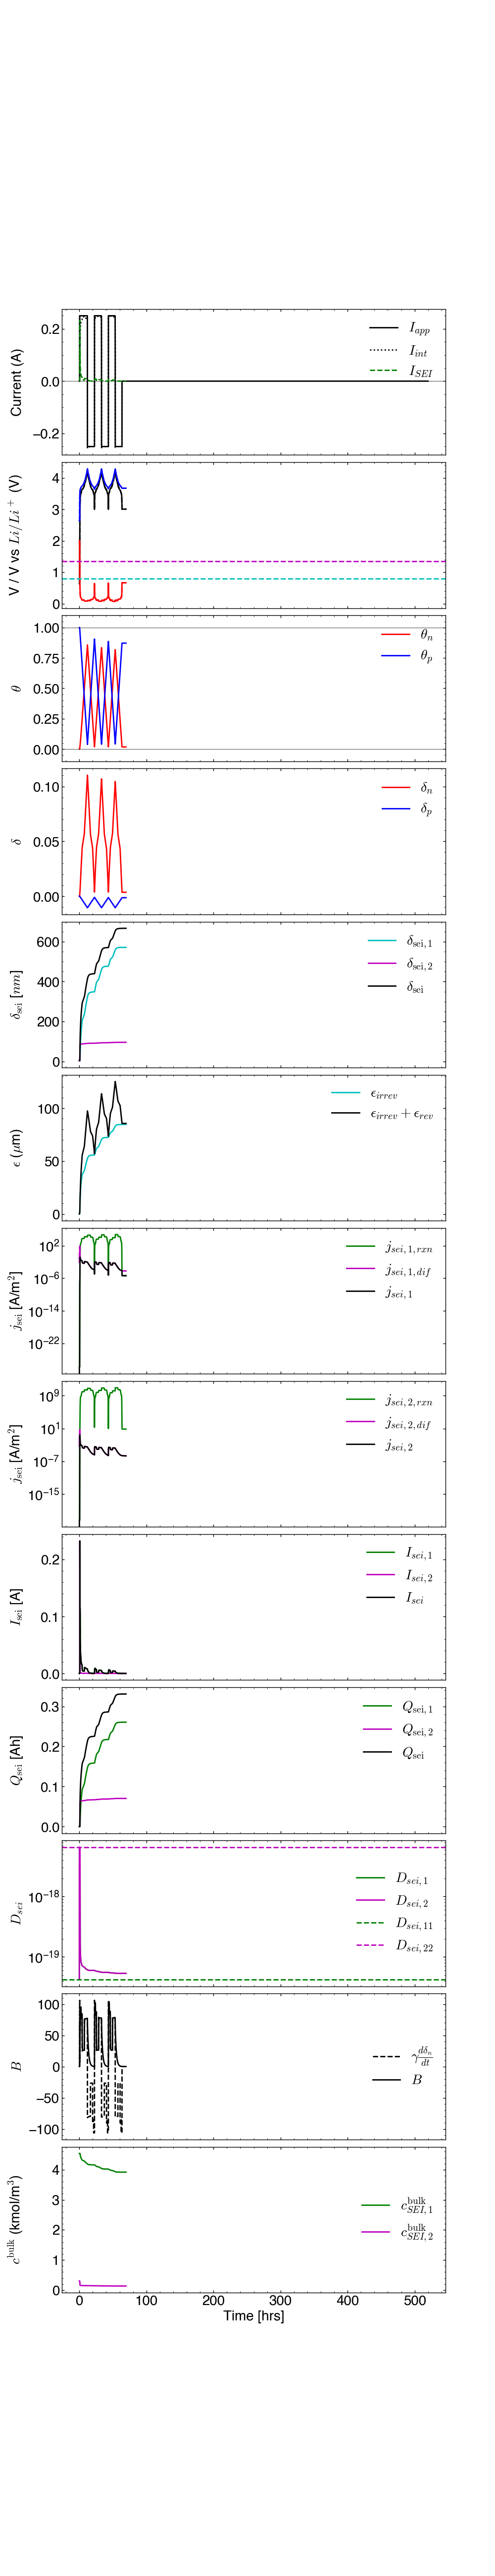

In [10]:

# %matplotlib widget
sim1.plot()


# Run the simulation: fast formation

In [ ]:
%autoreload

cell = cellsim.Cell()
cell.load_config('params/default.yaml')

# sim = cellsim.Simulation(cell, 520*3600)
sim2 = cellsim.Simulation(cell, 20*3600)

# Formation
sim2.run_rest(1, rest_time_hrs=0.5)
sim2.run_chg_cccv(2, 2.5, 2.5, 3.9)
sim2.run_chg_cccv(2, 2.5/5, 0.125, 4.2)
sim2.run_rest(2, rest_time_hrs=1/6)
sim2.run_dch_cccv(2, -2.5/5, 2.5/5, 3.9)
sim2.run_rest(2, rest_time_hrs=1/6)
sim2.run_chg_cccv(3, 2.5/5, 0.125, 4.2)
sim2.run_rest(3, rest_time_hrs=1/6)
sim2.run_dch_cccv(3, -2.5/5, 2.5/5, 3.9)
sim2.run_rest(3, rest_time_hrs=1/6)
sim2.run_chg_cccv(4, 2.5/5, 0.125, 4.2)
sim2.run_rest(4, rest_time_hrs=1/6)
sim2.run_dch_cccv(4, -2.5/5, 2.5/5, 3.9)
sim2.run_rest(4, rest_time_hrs=1/6)
sim2.run_chg_cccv(5, 2.5/5, 0.125, 4.2)
sim2.run_rest(5, rest_time_hrs=1/6)
sim2.run_dch_cccv(5, -2.5/5, 2.5/5, 3.9)
sim2.run_dch_cccv(5, -2.5/1, 0.05, 3.0)
sim2.run_rest(6, rest_time_hrs=3)

sim2_time1 = sim2.get_results()['t'].iloc[-1]/3600

df_sim2 = sim2.get_results()

Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...


/Users/aweng/code/formation-modeling/src/cellsim.py:1033: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'outputs/figures/{fig_name}.png',
/Users/aweng/code/formation-modeling/venv/lib/python3.8/site-packages/ipympl/backend_nbagg.py:336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.figure.savefig(buf, format='png', dpi='figure')


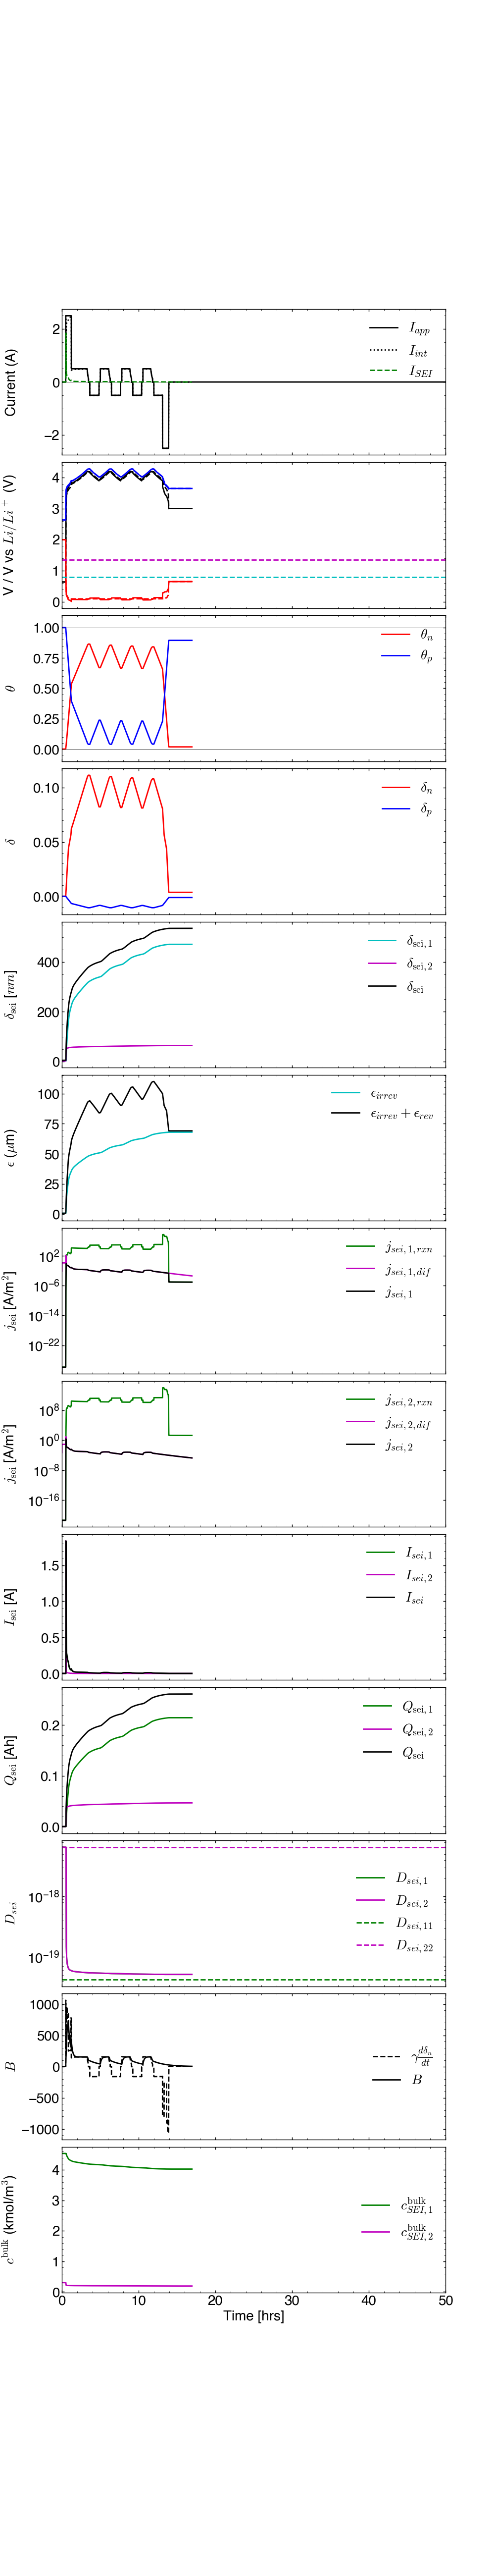

In [ ]:
%matplotlib widget
sim2.plot()


# Running the simulation: Fast+ Formation

In [ ]:
%autoreload

cell = cellsim.Cell()
cell.load_config('params/default.yaml')

# sim = cellsim.Simulation(cell, 520*3600)
sim3 = cellsim.Simulation(cell, 10*3600)

# Formation
sim3.run_rest(1, rest_time_hrs=0.5)
sim3.run_chg_cccv(2, 5.0, 5.0, 3.9)
sim3.run_chg_cccv(2, 2.5, 0.125, 4.2)
sim3.run_rest(2, rest_time_hrs=1/6)
sim3.run_dch_cccv(2, -2.5, 2.5, 3.9)
sim3.run_rest(2, rest_time_hrs=1/6)
sim3.run_chg_cccv(3, 2.5, 0.125, 4.2)
sim3.run_rest(3, rest_time_hrs=1/6)
sim3.run_dch_cccv(3, -2.5, 2.5, 3.9)
sim3.run_rest(3, rest_time_hrs=1/6)
sim3.run_chg_cccv(4, 2.5, 0.125, 4.2)
sim3.run_rest(4, rest_time_hrs=1/6)
sim3.run_dch_cccv(4, -2.5, 2.5, 3.9)
sim3.run_rest(4, rest_time_hrs=1/6)
sim3.run_chg_cccv(5, 2.5, 2.5, 4.2)
sim3.run_rest(2, rest_time_hrs=1/6)
sim3.run_dch_cccv(5, -2.5, 2.5, 3.9)
sim3.run_dch_cccv(5, -5.0, 0.05, 3.0)
sim3.run_rest(6, rest_time_hrs=3)

sim3_time1 = sim3.get_results()['t'].iloc[-1]/3600

df_sim3 = sim3.get_results()


Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...


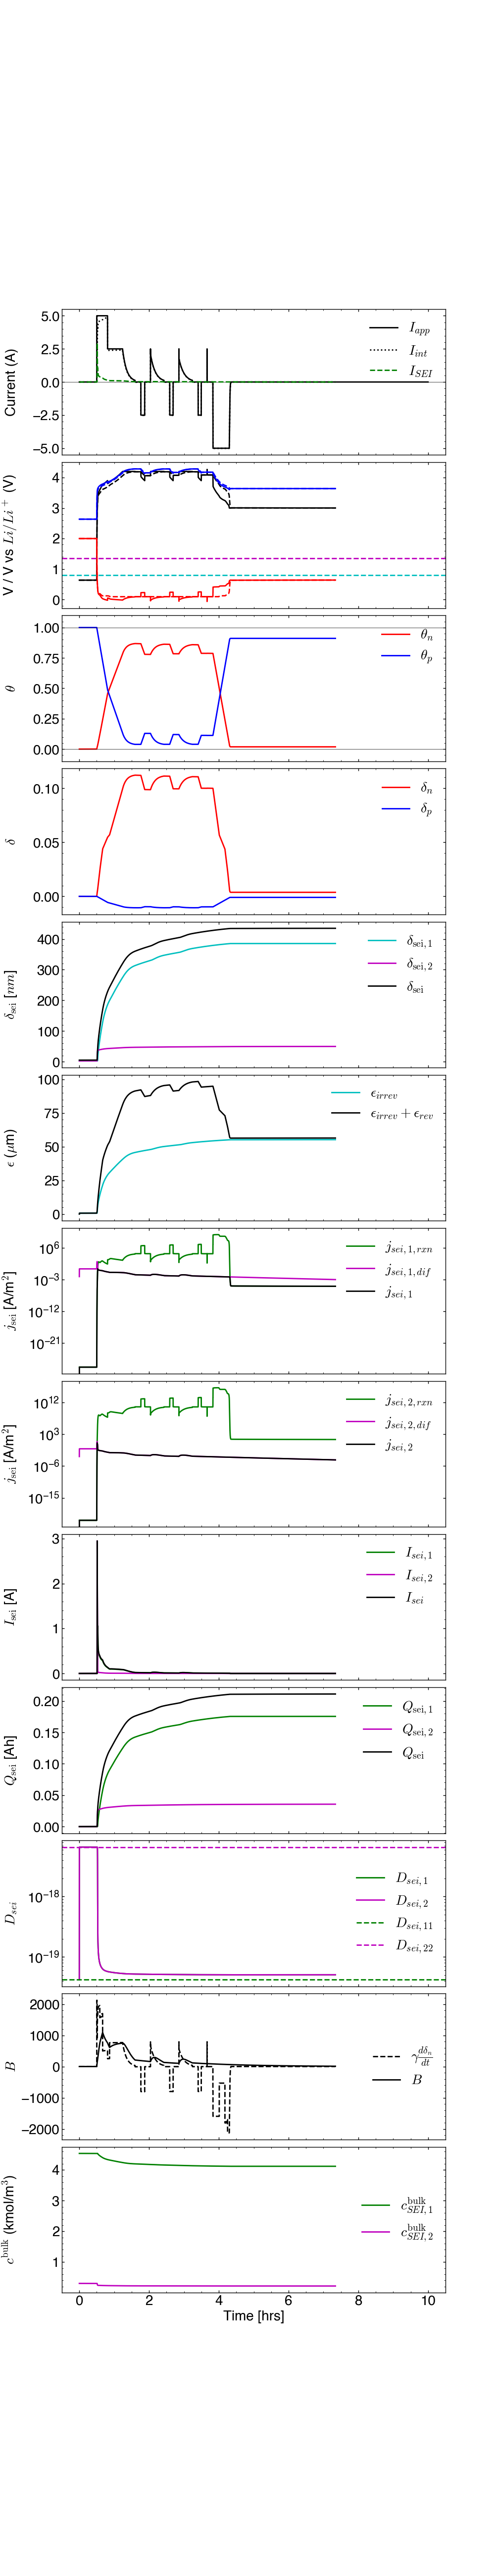

In [21]:
%matplotlib widget
sim3.plot()

# Overlay all experimental and model data

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_77185/1591710124.py:36: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,5))


(-0.1, 30.0)

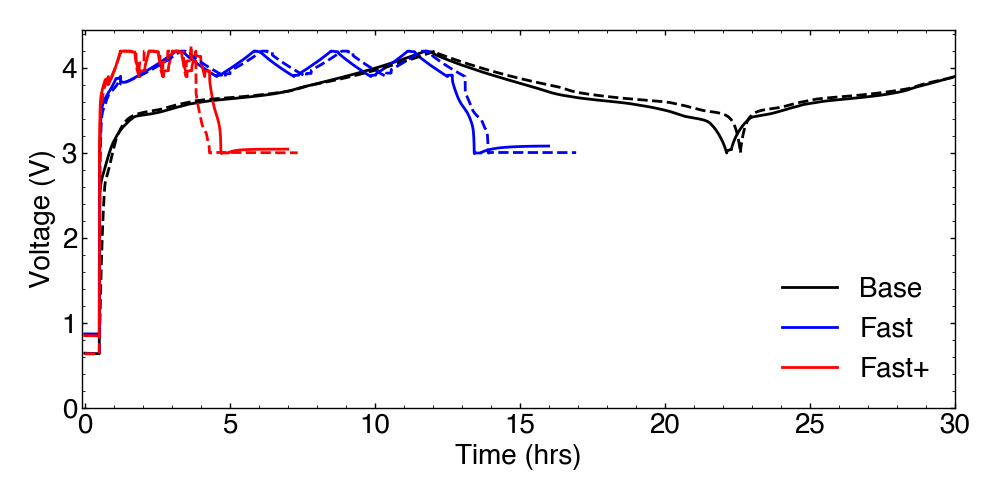

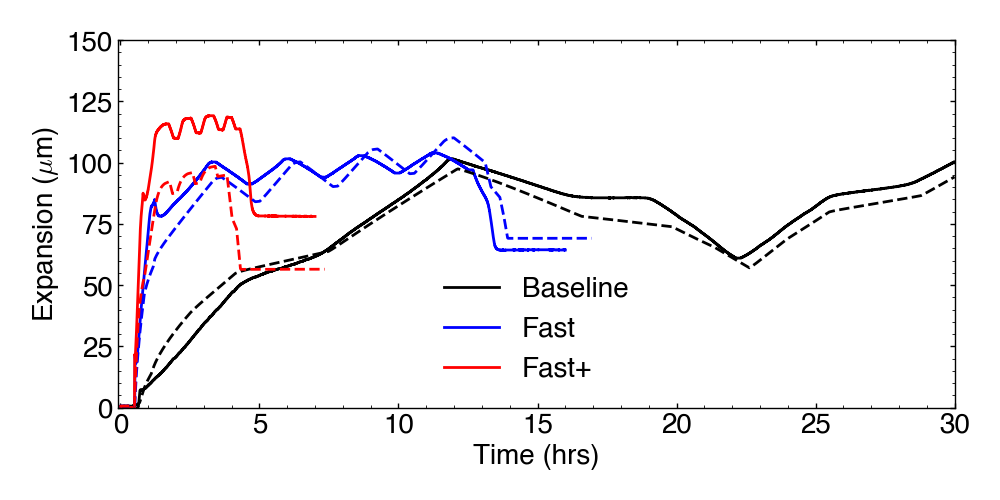

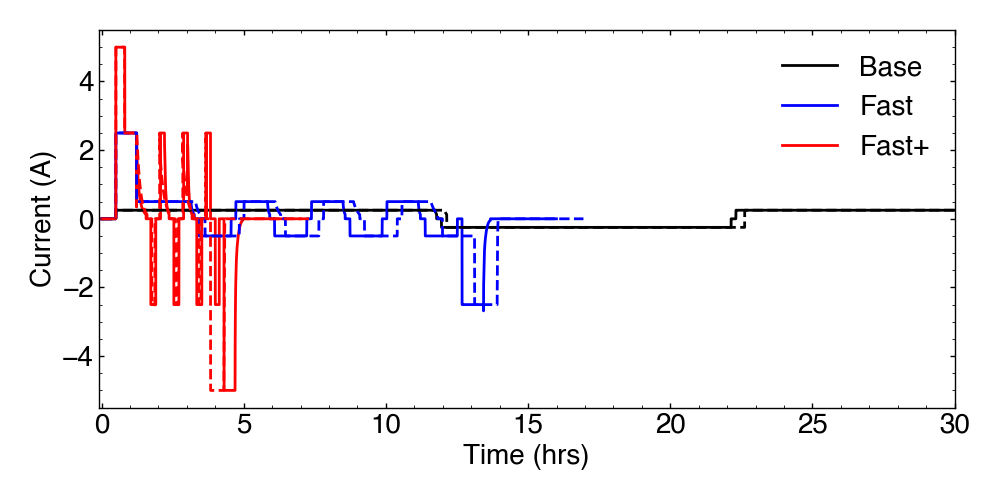

In [35]:

XLIM = (-0.1, 30)

# The voltage plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label='Base')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label='Fast')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label='Fast+')
ax.plot(df_sim1['t']/3600, df_sim1['vt'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['vt'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Voltage (V)')
ax.set_ylim(bottom=0)
ax.legend()
ax.grid(False)
ax.set_xlim(XLIM)

# The expansion plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label='Baseline')
ax.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label='Fast')
ax.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label='Fast+')
ax.plot(df_sim1['t']/3600, (df_sim1['expansion_irrev'] + df_sim1['expansion_rev'])*1e6, color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, (df_sim2['expansion_rev'] + df_sim2['expansion_irrev'])*1e6, color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, (df_sim3['expansion_rev'] + df_sim3['expansion_irrev'])*1e6, color='r', ls='--', label='')
ax.legend()
ax.set_ylabel(r'Expansion ($\mu$m)')
ax.set_ylim(bottom=0, top=150)
ax.set_xlim(XLIM)
ax.set_xlabel('Time (hrs)')
ax.grid(False)

# The current plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax.plot(df_sim1['t']/3600, df_sim1['i_app'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['i_app'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['i_app'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Current (A)')
ax.legend()
ax.grid(False)
ax.set_xlim(XLIM)


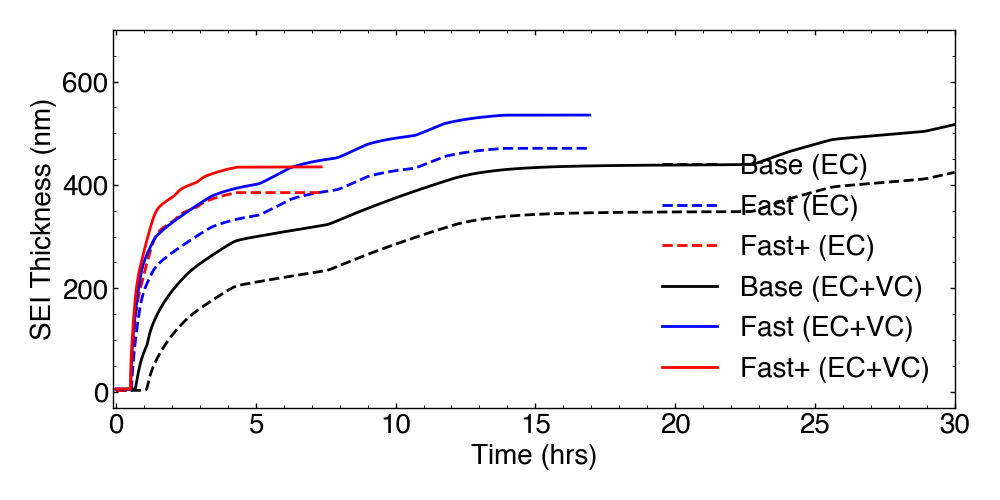

In [33]:


plt.figure(figsize=(10,5))
ax4 = plt.gca()
ax4.plot(df_sim1['t']/3600, df_sim1['delta_sei1']*1e9, color='k', ls='--', label='Base (EC)')
ax4.plot(df_sim2['t']/3600, df_sim2['delta_sei1']*1e9, ls='--', color='b', label='Fast (EC)')
ax4.plot(df_sim3['t']/3600, df_sim3['delta_sei1']*1e9, ls='--', color='r', label='Fast+ (EC)')
ax4.plot(df_sim1['t']/3600, (df_sim1['delta_sei'])*1e9, color='k', ls='-', label='Base (EC+VC)')
ax4.plot(df_sim2['t']/3600, (df_sim2['delta_sei'])*1e9, color='b', ls='-', label='Fast (EC+VC)')
ax4.plot(df_sim3['t']/3600, (df_sim3['delta_sei'])*1e9, color='r', ls='-', label='Fast+ (EC+VC)')
ax4.legend()
ax4.set_ylabel('SEI Thickness (nm)')
ax4.set_xlim(XLIM)
ax4.set_xlabel('Time (hrs)')
ax4.grid(False)
ax2 = plt.gca()

In [31]:
# Create a table comparing SEI growth across different protocols
df_result = pd.DataFrame()

# Create column headers for different time points
time_points = ['2 hrs', 'After Formation Cycles']

protocols = []
total_sei = []
vc_pcts = []
D_sei1 = []
D_sei2 = []

 # Base formation (sim1)
for t in [2*3600, sim1_time1*3600]:
    q_sei = df_sim1[df_sim1['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim1[df_sim1['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Base')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim1[df_sim1['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim1[df_sim1['t'] <= t]['D_sei2'].iloc[-1])

# Fast formation (sim2)
for t in [2*3600, sim2_time1*3600]:
    q_sei = df_sim2[df_sim2['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim2[df_sim2['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim2[df_sim2['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim2[df_sim2['t'] <= t]['D_sei2'].iloc[-1])

# Fast+ formation (sim3)
for t in [2*3600, sim3_time1*3600]:
    q_sei = df_sim3[df_sim3['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim3[df_sim3['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast+')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim3[df_sim3['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim3[df_sim3['t'] <= t]['D_sei2'].iloc[-1])


df_result = pd.DataFrame({
    'Protocol': protocols,
    'Time Point': time_points * 3,
    'Total SEI (Ah)': total_sei,
    'VC SEI %': vc_pcts,
    'D_sei1': D_sei1,
    'D_sei2': D_sei2
})


print(df_result.to_string(index=False))

Protocol             Time Point  Total SEI (Ah)  VC SEI %       D_sei1       D_sei2
    Base                  2 hrs        0.111643 56.374311 9.548833e-20 9.548833e-20
    Base After Formation Cycles        0.330934 21.252287 5.324344e-20 5.324344e-20
    Fast                  2 hrs        0.164138 25.702628 5.640542e-20 5.640542e-20
    Fast After Formation Cycles        0.261448 17.878701 5.107310e-20 5.107310e-20
   Fast+                  2 hrs        0.183375 18.493594 5.145540e-20 5.145540e-20
   Fast+ After Formation Cycles        0.211099 16.893477 5.047226e-20 5.047226e-20


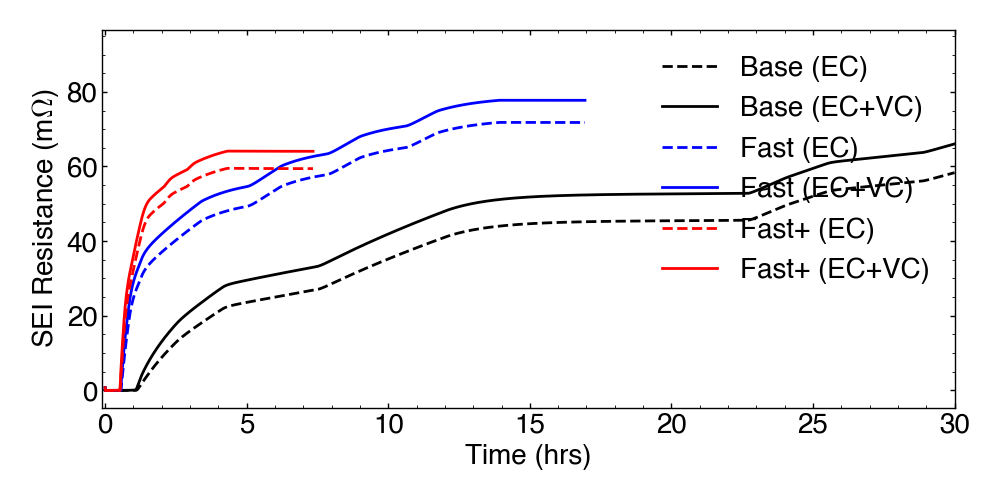

In [32]:


plt.figure(figsize=(10,5))
ax4 = plt.gca()
ax4.plot(df_sim1['t']/3600, df_sim1['R_sei1']*1000, color='k', label='Base (EC)', ls='--')
ax4.plot(df_sim1['t']/3600, df_sim1['R_sei']*1000, color='k', label='Base (EC+VC)', ls='-')
ax4.plot(df_sim2['t']/3600, df_sim2['R_sei1']*1000, color='b', ls='--', label='Fast (EC)')
ax4.plot(df_sim2['t']/3600, df_sim2['R_sei']*1000, color='b', ls='-', label='Fast (EC+VC)')
ax4.plot(df_sim3['t']/3600, df_sim3['R_sei1']*1000, color='r', ls='--', label='Fast+ (EC)')
ax4.plot(df_sim3['t']/3600, df_sim3['R_sei']*1000, color='r', ls='-', label='Fast+ (EC+VC)')
ax4.legend()
ax4.set_ylabel(r'SEI Resistance (m$\Omega$)')

ax4.set_xlim(XLIM)
ax4.set_xlabel('Time (hrs)')
ax4.grid(False)